In [2]:
# CELL 1: DIRECT KAGGLE EXTRACTION (NO GOOGLE DRIVE NEEDED)
import os
import pandas as pd
import zipfile
import shutil
from sklearn.model_selection import train_test_split

# 1. Setup Kaggle
os.environ['KAGGLE_API_TOKEN'] = "KGAT_f0b1c8ff434df72d865d509e7cacd6cb"

print("1. Downloading 42GB dataset directly from Kaggle... (Takes 3-5 minutes)")
!kaggle datasets download -d nih-chest-xrays/data

# Identify the downloaded file
local_zip_path = '/content/data.zip' if os.path.exists('/content/data.zip') else '/content/nih-chest-xrays.zip'

print("2. Reading patient records directly from the zip...")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    csv_filename = [f for f in z.namelist() if f.endswith('Data_Entry_2017.csv')][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

print("3. Selecting 2,000 patients for High-Accuracy Training...")
normal_df = df[df['Finding Labels'] == 'No Finding'].head(1000)
effusion_df = df[df['Finding Labels'].str.contains('Effusion')].head(1000)
full_df = pd.concat([normal_df, effusion_df])

# THE FIX: Create a clean column for the splitter to use
full_df['Clean_Target'] = full_df['Finding Labels'].apply(lambda x: 'Normal' if x == 'No Finding' else 'Effusion')

# Now we stratify using our Clean_Target column instead of the messy original labels
train_df, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['Clean_Target'])

def extract_images(zip_file, dataframe, base_path):
    os.makedirs(os.path.join(base_path, 'Normal'), exist_ok=True)
    os.makedirs(os.path.join(base_path, 'Effusion'), exist_ok=True)
    all_files = {os.path.basename(f): f for f in zip_file.namelist() if f.endswith('.png')}

    count = 0
    for _, row in dataframe.iterrows():
        img_name = row['Image Index']
        label = 'Normal' if row['Finding Labels'] == 'No Finding' else 'Effusion'
        if img_name in all_files:
            source = zip_file.open(all_files[img_name])
            target = open(os.path.join(base_path, label, img_name), "wb")
            with source, target:
                shutil.copyfileobj(source, target)
            count += 1
    return count

print("4. Sniper Extraction: Pulling ONLY the 2,000 images out... (Safe for Colab!)")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    train_count = extract_images(z, train_df, '/content/model_data/train')
    val_count = extract_images(z, val_df, '/content/model_data/val')

print("5. PURGING THE MASSIVE ZIP FILE TO FREE UP COLAB STORAGE...")
os.remove(local_zip_path)

print(f"\n✅ DATA EXTRACTION SUCCESS!")
print(f"Training Images: {train_count} | Validation: {val_count}")
print("Your storage is completely safe and empty. Proceed to Cell 3 (Vision System)!")

1. Downloading 42GB dataset directly from Kaggle... (Takes 3-5 minutes)
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
data.zip: Skipping, found more recently modified local copy (use --force to force download)
2. Reading patient records directly from the zip...
3. Selecting 2,000 patients for High-Accuracy Training...
4. Sniper Extraction: Pulling ONLY the 2,000 images out... (Safe for Colab!)
5. PURGING THE MASSIVE ZIP FILE TO FREE UP COLAB STORAGE...

✅ DATA EXTRACTION SUCCESS!
Training Images: 1600 | Validation: 400
Your storage is completely safe and empty. Proceed to Cell 3 (Vision System)!


In [4]:
# CELL 3: HIGH-DEF VISION SYSTEM (FOR EFFICIENTNET-B3)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Setting up the High-Definition Vision System for B3...")

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

# UPGRADE: Changed target_size to 300x300 and batch_size to 16 to protect RAM
train_generator = train_datagen.flow_from_directory(
    '/content/model_data/train',
    target_size=(300, 300),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion']
)

val_generator = val_datagen.flow_from_directory(
    '/content/model_data/val',
    target_size=(300, 300),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion'],
    shuffle=False
)

print("Vision system ready!")

Setting up the High-Definition Vision System for B3...
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Vision system ready!


In [6]:
# CELL 4: EFFICIENTNET-B3 EXTENDED TRAINING ARCHITECTURE
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("Building the Heavy-Duty EfficientNet-B3 Architecture...")

base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_eff = Model(inputs=base_model.input, outputs=predictions)

model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# THE UPGRADE: Saving as .h5 directly to your Google Drive!
model_save_path = '/content/drive/MyDrive/best_efficientnet_B3_nih.h5'

checkpoint = ModelCheckpoint(model_save_path, monitor='val_accuracy',
                             save_best_only=True, mode='max', verbose=1)

# UPGRADE: Extended patience to 8 since we are running more epochs
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

print("\nStarting Extended 30-Epoch Deep Training Run...")
# UPGRADE: Pushed the maximum epochs to 30
history = model_eff.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

print(f"\n✅ Training Complete! Your best B3 model is safely locked in your Google Drive at: {model_save_path}")

Building the Heavy-Duty EfficientNet-B3 Architecture...

Starting Extended 30-Epoch Deep Training Run...
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.6376 - loss: 0.6439
Epoch 1: val_accuracy improved from None to 0.71500, saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.6862 - loss: 0.6056 - val_accuracy: 0.7150 - val_loss: 0.5923
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.7332 - loss: 0.5266
Epoch 2: val_accuracy did not improve from 0.71500
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 809ms/step - accuracy: 0.7481 - loss: 0.5220 - val_accuracy: 0.6625 - val_loss: 0.5899
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.8006 - loss: 0.4396
Epoch 3: val_accuracy improved from 0.71500 to 0.75500, saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 817ms/step - accuracy: 0.7981 - loss: 0.4417 - val_accuracy: 0.7550 - val_loss: 0.5180
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.8273 - loss: 0.3913
Epoch 4: val_accuracy improved from 0.75500 to 0.79500, saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_efficientnet_B3_nih.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 807ms/step - accuracy: 0.8188 - loss: 0.4115 - val_accuracy: 0.7950 - val_loss: 0.5120
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.8409 - loss: 0.3469
Epoch 5: val_accuracy did not improve from 0.79500
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 800ms/step - accuracy: 0.8388 - loss: 0.3506 - val_accuracy: 0.7625 - val_loss: 0.6469
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.8842 - loss: 0.2932
Epoch 6: val_accuracy did not improve from 0.79500
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 801ms/step - accuracy: 0.8687 - loss: 0.3168 - val_accuracy: 0.7625 - val_loss: 0.6124
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.8940 - loss: 0.2499
Epoch 7: val_accuracy did not improve from 0.79500
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 794ms/step - accuracy: 0.8906 - loss: 0.2538 - val_accuracy: 0.7675 - val_loss: 0.9289
Epoch 8/30
100/10

Generating Professional Training Curves...


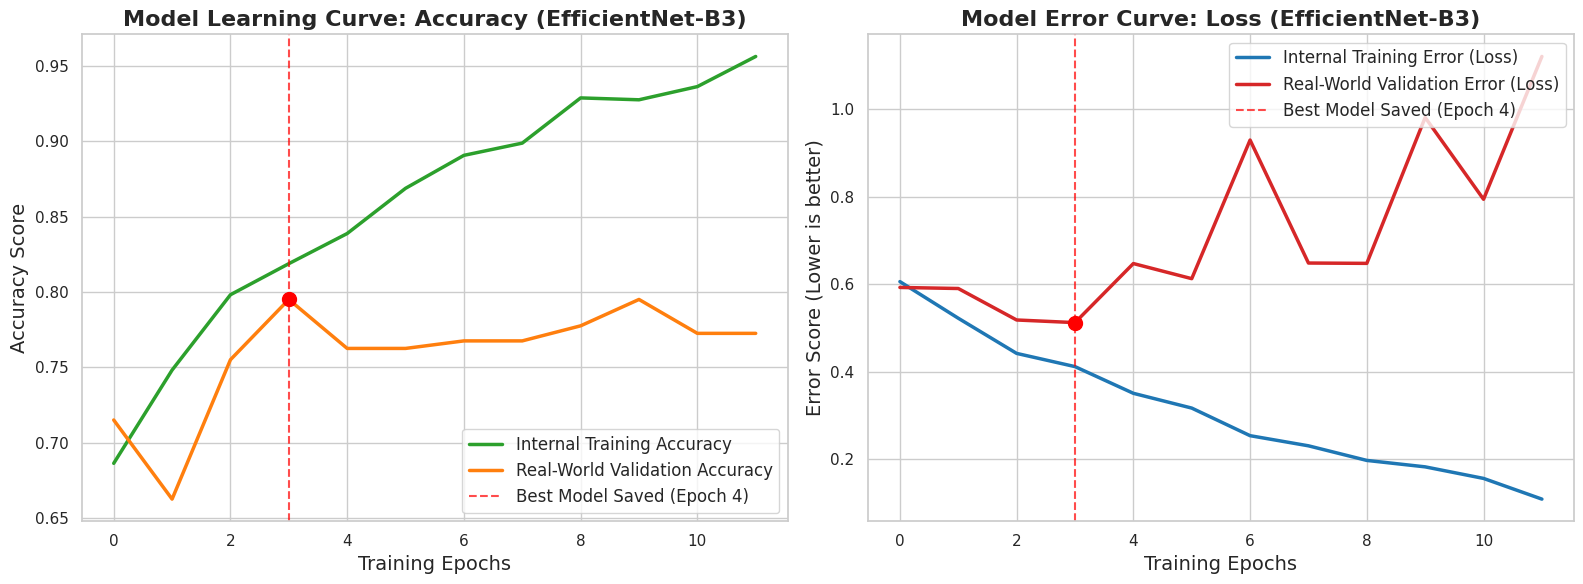


Final Locked Validation Accuracy: 79.50%


In [7]:
# PRESENTATION GRAPHICS: TRAINING HISTORY
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Professional Training Curves...")

# Set the style to look clean and professional
sns.set_theme(style="whitegrid")

# Create a wide image with 2 graphs side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Find the exact epoch where Early Stopping locked the model
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_val_loss = history.history['val_loss'][best_epoch]

# ---------------------------------------------------------
# GRAPH 1: ACCURACY CURVE
# ---------------------------------------------------------
ax1.plot(history.history['accuracy'], label='Internal Training Accuracy', linewidth=2.5, color='#2ca02c')
ax1.plot(history.history['val_accuracy'], label='Real-World Validation Accuracy', linewidth=2.5, color='#ff7f0e')

# Draw a red line showing exactly where the best model was saved
ax1.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Model Saved (Epoch {best_epoch+1})')
ax1.scatter(best_epoch, best_val_acc, color='red', s=100, zorder=5)

ax1.set_title('Model Learning Curve: Accuracy (EfficientNet-B3)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Training Epochs', fontsize=14)
ax1.set_ylabel('Accuracy Score', fontsize=14)
ax1.legend(loc='lower right', fontsize=12)

# ---------------------------------------------------------
# GRAPH 2: LOSS (ERROR) CURVE
# ---------------------------------------------------------
ax2.plot(history.history['loss'], label='Internal Training Error (Loss)', linewidth=2.5, color='#1f77b4')
ax2.plot(history.history['val_loss'], label='Real-World Validation Error (Loss)', linewidth=2.5, color='#d62728')

# Draw a red line showing exactly where the best model was saved
ax2.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Model Saved (Epoch {best_epoch+1})')
ax2.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5)

ax2.set_title('Model Error Curve: Loss (EfficientNet-B3)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Training Epochs', fontsize=14)
ax2.set_ylabel('Error Score (Lower is better)', fontsize=14)
ax2.legend(loc='upper right', fontsize=12)

# Display the graphs cleanly
plt.tight_layout()
plt.show()

print(f"\nFinal Locked Validation Accuracy: {best_val_acc*100:.2f}%")